In [2]:
import src.analysis_functions as af
import src.data_functions as data_func
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np
import os
import pandas as pd
import importlib
from scipy import stats

importlib.reload(af)
importlib.reload(data_func)

<module 'src.data_functions' from 'C:\\Users\\owner\\Documents\\Projects\\rnaseq_correlations\\src\\data_functions.py'>

C:\Users\owner\Documents\Projects\rnaseq_correlations\src\analysis_functions.py:27: RuntimeWarning: invalid value encountered in divide
  m = (m - m.mean(axis=0)) / m.std(axis=0)
C:\Users\owner\AppData\Local\Temp\ipykernel_55916\3177838571.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


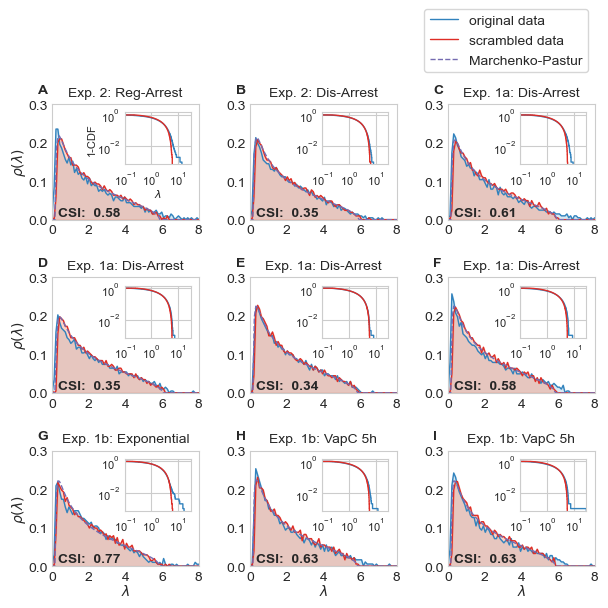

In [24]:
# additional data
# Set font size globally
fsize = 10
# get list of files in data directory
data_dir = r'C:\Users\owner\Documents\Projects\rnaseq_correlations\data_for_paper'
# read the files data
datasets = pd.read_csv(os.path.join(data_dir, 'titles.csv'),index_col=0)
files = datasets.index.values

# list of files with '*.csv' extension
fig, ax = plt.subplots(3, 3, figsize=(7, 6), gridspec_kw={'hspace': 0.5, 'wspace': 0.35})
x_max = 8
y_max = 0.25
n_bins=81
for i,file in enumerate(files):
    amat = data_func.read_from_csv(os.path.join(data_dir, file+'.csv'))
    m = amat.m
    N, P = m.shape
    pcs, pcs1 = af.get_eig_dist(m, norm=True, log=False, norm_method='sum', norm_sum=1)
    # get indices for subplot
    y = np.mod(i,3)
    x = int(i/3)
    # plot the pdfs
    if x==2:
        x_label=True
    else:
        x_label=False
    if y==0:
        y_label=True
    else:
        y_label=False
    data_func.plot_eig_dist(pcs, pcs1, N, x_max, y_max, n_bins, ax=ax[x,y], x_label=x_label, y_label=y_label)
    # axes properties:
    # set title
    ax[x,y].set_title(datasets.loc[file]['title'], fontsize = fsize)
    ax[x,y].grid(False)
    ax[x,y].legend_.remove()
    # plot the cdfs in the inset
    pcs=pcs[pcs>0]
    pcs1=pcs1[pcs1>0]
    # print max eigenvalue value in the plot
    ax[x,y].text(0.3, 0.01, r"CSI: "+f" {round(datasets.loc[file]['CSI'], 2)}", size=fsize, weight='bold')
    # add panel letter
    ax[x,y].text(-0.1, 1.1, chr(65+i), transform=ax[x,y].transAxes, size=fsize, weight='bold')
    # set ticks
    ax[x,y].tick_params(axis='both', which='major', labelsize=fsize, pad=0)
    # set line width:
    for line in ax[x,y].lines:            # ax.get_lines() is equivalent
        line.set_linewidth(1)
    # set title & labels
    ax[x,y].title.set_fontsize(fsize)
    ax[x,y].xaxis.label.set_size(fsize)
    ax[x,y].yaxis.label.set_size(fsize)
    ax[x,y].xaxis.labelpad = 0
    ax[x,y].yaxis.labelpad = 0
    inset_ax = inset_axes(ax[x,y],width="45%", height="45%", loc='upper right')  # [x0, y0, width, height] in relative coordinates
    res = stats.ecdf(pcs)
    res.sf.plot(ax=inset_ax, color='#3182bd',linewidth=1)
    
    res = stats.ecdf(pcs1)
    res.sf.plot(ax=inset_ax, color='#de2d26',linewidth=1)
    # set to log scale
    inset_ax.set_yscale('log')
    inset_ax.set_xscale('log')
    if x==0 and y==0:
        inset_ax.set_ylabel('1-CDF', fontsize = fsize-2)
        inset_ax.set_xlabel('$\lambda$', fontsize = fsize-2)
    # set xmin
    inset_ax.set_xlim([0.1, 30])
        # set ticks
    inset_ax.tick_params(axis='both', which='major', labelsize=fsize-2, pad=0)
    
    # set title & labels
    inset_ax.title.set_fontsize(fsize-2)
    inset_ax.xaxis.label.set_size(fsize-2)
    inset_ax.yaxis.label.set_size(fsize-2)
    inset_ax.yaxis.labelpad = 0
    inset_ax.xaxis.labelpad = 0
    # set title
# plot legend
# Collect handles and labels from the first subplot (or all subplots)
handles, labels = [], []
for a in ax.flat:
    for handle, label in zip(*a.get_legend_handles_labels()):
        if label not in labels:  # Avoid duplicates
            handles.append(handle)
            labels.append(label)

# Add a single legend for all subplots
fig.legend(handles, labels, loc="upper right", ncol=1, bbox_to_anchor=(0.9, 1.05), fontsize=fsize)
# save the figure
output_dir = r'G:\Other computers\My MacBook Air\Alon\PhD\correlations paper\new figures\supplementary figures'
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'figure s2.pdf'), format='pdf', dpi=300, bbox_inches='tight')
plt.show()

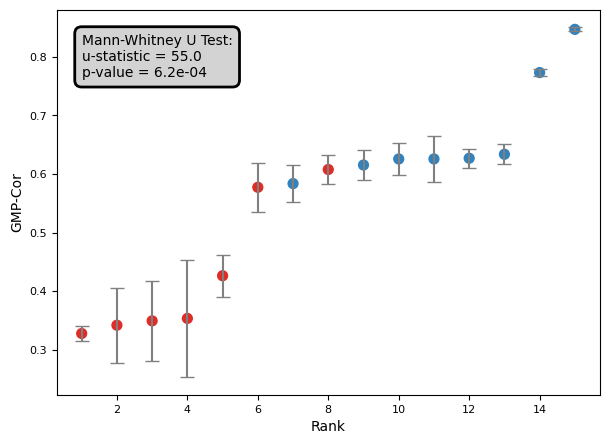

In [1]:
# significance test
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
import numpy as np
import os
import pandas as pd

plt.style.use('default')
fontsize=10
blue='#3182bd'
red='#de2d26'
# load data
path = "G:\Other computers\My MacBook Air\Alon\PhD\correlations paper\summary of datasets\dataset_summary_no_plasmid_genes.csv"
df = pd.read_csv(path, header=0)
ranking_param = 'sigma fit'
# plot rank plot of p-values with plotly
# remove VapC early and late
# Sort values and compute rank
df['Rank'] = df[ranking_param].rank(method='min').astype(int)
# perform statistical test:

# Split data into two groups based on labels
group1 = df[df['class'] == 'reg'][ranking_param]
group0 = df[df['class'] == 'dis'][ranking_param]

# Perform Mann-Whitney U Test
u_stat, u_pval = mannwhitneyu(group1, group0, alternative='two-sided')
# Sort DataFrame by rank for proper plotting
df_sorted = df.sort_values('Rank')
# Create scatter plot
fig, ax = plt.subplots(figsize=(7, 5))

ax.errorbar(df_sorted['Rank'], df_sorted[ranking_param], yerr=df_sorted['standard error'], fmt='none', color='grey', capsize=5)
ax.scatter(df_sorted['Rank'], df_sorted[ranking_param], s=50,c=df_sorted['class'].map({'reg': blue, 'dis': red}))
ax.set_xlabel('Rank', fontsize=fontsize)
ax.set_ylabel(r'GMP-Cor', fontsize=fontsize)
# set xtick size
ax.tick_params(axis='x', labelsize=fontsize-2)
# set ytick size
ax.tick_params(axis='y', labelsize=fontsize-2)
text = ax.text(
    1, 0.8,  # Position in axis coordinates (x=0.5, y=0.8)
    f"Mann-Whitney U Test:\nu-statistic = {u_stat}\np-value = {u_pval:.1e}",  # Text content
    fontsize=fontsize,
    color='black',
    ha='left',  # Horizontal alignment
    va='center',  # Vertical alignment
    bbox=dict(
        boxstyle="round,pad=0.5",  # Rounded rectangle with padding
        edgecolor="black",  # Border color
        facecolor="lightgray",# Background color
        linewidth=2  # Border thickness
    )
)
# save the figure
output_dir = r'G:\Other computers\My MacBook Air\Alon\PhD\correlations paper\new figures\supplementary figures'
plt.savefig(os.path.join(output_dir, 'figure s3.pdf'), format='pdf')
plt.show()

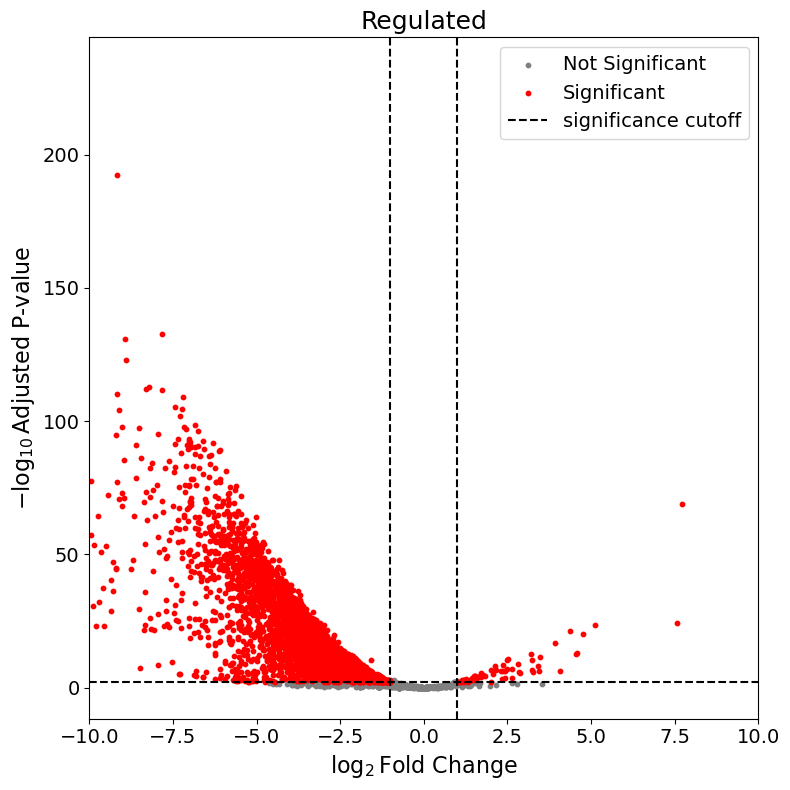

In [112]:
# Deseq2 volcano plots:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
fontsize=16
# Load the DEG results
file_name = 'deseq2_results_regulated.csv'
path = os.path.join(os.path.dirname(os.getcwd()), 'results', 'deseq_results', 'ercc_norm', file_name)
deg_results = pd.read_csv(path, index_col=0)

# Add a new column for -log10(padj)
deg_results['-log10(padj)'] = -np.log10(deg_results['padj'].replace(0, 1e-300))  # Avoid log(0)

# Define the cutoffs
p_cutoff = 0.01
lfc_cutoff = 1

# Select significant genes
significance = (deg_results['padj'] < p_cutoff) & (np.abs(deg_results['log2FoldChange']) > lfc_cutoff)
deg_results['significant'] = significance

# Create the volcano plot
plt.figure(figsize=(8, 8))

# Plot non-significant points
plt.scatter(
    deg_results.loc[~deg_results['significant'], 'log2FoldChange'],
    deg_results.loc[~deg_results['significant'], '-log10(padj)'],
    color='grey', s=10, label='Not Significant'
)

# Plot significant points
plt.scatter(
    deg_results.loc[deg_results['significant'], 'log2FoldChange'],
    deg_results.loc[deg_results['significant'], '-log10(padj)'],
    color='red', s=10, label='Significant'
)

# Add cutoff lines
plt.axhline(-np.log10(p_cutoff), color='black', linestyle='--', label='significance cutoff')
plt.axvline(lfc_cutoff, color='black', linestyle='--')
plt.axvline(-lfc_cutoff, color='black', linestyle='--')

# Set axis limits
plt.xlim([-10, 10])

# Add labels and title
plt.xlabel(r'$\log_2{\text{Fold Change}}$', fontsize=fontsize)
plt.ylabel(r'$-\log_{10}{\text{Adjusted P-value}}$', fontsize=fontsize)
plt.title('Regulated', fontsize=fontsize+2)
plt.xticks(fontsize=fontsize-2)
plt.yticks(fontsize=fontsize-2)

# Add legend
plt.legend(loc='upper right', fontsize=fontsize-2)

# Show the plot
plt.tight_layout()
# save the figure
output_dir = r'G:\Other computers\My MacBook Air\Alon\PhD\correlations paper\new figures\supplementary figures'
plt.savefig(os.path.join(output_dir, 'ercc_regulated.svg'), format='svg')
plt.show()


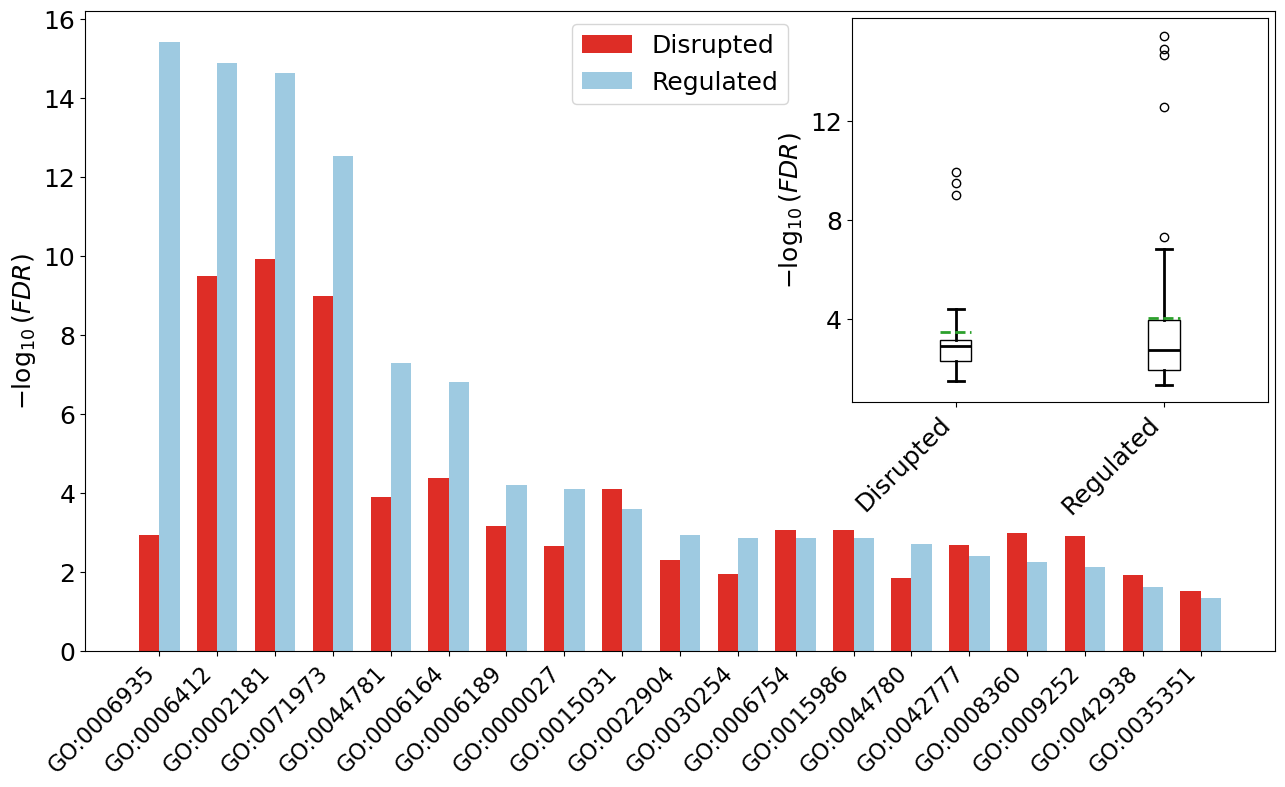

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import os
plt.style.use('default')
# compare p-values of GO terms
# Load the GO enrichment results
file_name = 'GOATOOLS_GO_enrichment_results_shx_down.csv'
path = os.path.join(os.path.dirname(os.getcwd()),'results','GO_results','from_counts',file_name)
go_results = pd.read_csv(path)
# load the second condition
file_name = 'GOATOOLS_GO_enrichment_results_casp_down.csv'
path = os.path.join(os.path.dirname(os.getcwd()),'results','GO_results','from_counts',file_name)
go_results2 = pd.read_csv(path)
#
#filter go terms that appear in both conditions
common_go_terms = set(go_results['GO_ID']).intersection(set(go_results2['GO_ID']))
# get the p-values of the common go terms
go_dict = {}
for go_term in common_go_terms:
    p_value1 = go_results[go_results['GO_ID'] == go_term]['FDR'].values[0]
    p_value2 = go_results2[go_results2['GO_ID'] == go_term]['FDR'].values[0]
    go_dict[go_term] = [p_value1, p_value2]

# create a dataframe
df = pd.DataFrame(go_dict).T
df.columns = ['SHX', 'Casp']
df = df.sort_values('Casp', ascending=True)
# plot bar plot of -log10(p-values) for each GO term
# Set font size
f_size = 18

# Set figure size
fig, ax = plt.subplots(figsize=(14, 8))
# make axis higher in the figure
fig.subplots_adjust(top=0.95, bottom=0.15, left=0.1, right=0.95)
# Define bar width
bar_width = 0.35

# Create bar positions for each group
x = np.arange(len(df.index))  # the label locations
shx_values = -np.log10(df['SHX'])
casp_values = -np.log10(df['Casp'])

# Plot each bar next to each other
ax.bar(x - bar_width/2, shx_values, width=bar_width, label='Disrupted', color='#de2d26')
ax.bar(x + bar_width/2, casp_values, width=bar_width, label='Regulated', color='#9ecae1')

# Set title and labels
ax.set_ylabel('$-\log_{10}{(FDR)}$', fontsize=f_size)
#ax.set_xlabel('Index')
ax.set_xticks(x)  # Set x-ticks to be at the center of each pair
ax.set_xticklabels(df.index, fontsize=f_size-2)  # Set x-tick labels to match the DataFrame index
plt.xticks(rotation=45, ha='right', fontsize=f_size-2)  # Rotate x-tick labels for better visibility
# Add legend
ax.legend(fontsize=f_size, loc='upper center')
plt.yticks(fontsize=f_size)


# add inset
inset_ax = inset_axes(ax,width="35%", height="60%", loc='upper right')
c="k"
inset_ax.boxplot([-np.log10(go_results['FDR']), -np.log10(go_results2['FDR'])], meanline=True, showmeans=True, patch_artist=True, boxprops=dict(facecolor="None", color=c), whiskerprops=dict(color=c), capprops=dict(color=c), flierprops=dict(markeredgecolor=c), medianprops=dict(color=c))
#set line width of boxplot
for line in inset_ax.lines:
    line.set_linewidth(2)
    
inset_ax.set_xticklabels(['Disrupted', 'Regulated'], fontsize=f_size, rotation=45, ha='right')
inset_ax.set_ylabel('$-\log_{10}{(FDR)}$', fontsize=f_size)
inset_ax.set_yticks([4,8,12])
inset_ax.set_yticklabels([4,8,12],fontsize=f_size)
# Save as SVG
output_folder = r'G:\Other computers\My MacBook Air\Alon\PhD\correlations paper\new figures\supplementary figures'
#fig.savefig(os.path.join(output_folder,'GO_pvalues_deseq2_norm.svg'), format='svg')

# Show the plot
plt.show()

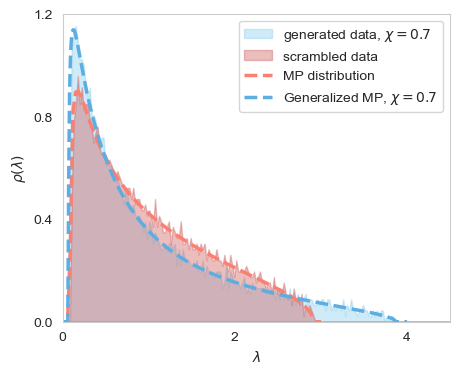

In [8]:
# numerical validation of analytical results:
# plot the computer generated data
# Generate random data with true correlations
np.random.seed(0)
N=4000
P = 2000
sigma=0.7
A=np.random.normal(0,sigma,(P,P))
H=np.dot(A,A.transpose())/P+(1-sigma**2)*np.identity(P)
L=np.linalg.cholesky(H)
data = np.random.normal(0,1,(N,P))
data = L@data.T
data = data.T
# plot parameters:
x_max=4.5
y_max=1.2
n_bins = 201
edges = np.linspace(-0.1, x_max, num=n_bins)
# plot the correlation spectrum:
pcs, pcs1 = af.get_eig_dist(data, norm=False, log=False, norm_method='sum')
# plot histograms of eigenvalues
fig, ax = plt.subplots(figsize=(5, 4))
# first plot
counts, bins = np.histogram(pcs, bins=edges, density=True)
#ax.plot(bins[1:], counts, color='#3182bd', linewidth=2, label='original data')
ax.fill_between(bins[1:], counts, 0, color='#87CEEB', alpha=.4, label='generated data, $\chi=0.7$')
# second plot
counts, bins = np.histogram(pcs1, bins=edges, density=True)
#ax.plot(bins[1:], counts, color='#de2d26', linewidth=2, label='scrambled data')
ax.fill_between(bins[1:],counts, 0, color='#CD5C5C', alpha=.4, label='scrambled data')
# plot analytical Marchenko-Pastur distribution
x = np.linspace(-0.1, 3, 100)
y = [af.mp_distribution(val, P / N) for val in x]
ax.plot(x, y, color='#FA8072',linewidth=2.5 ,linestyle='dashed', label='MP distribution')
# plot analytical generalized Marchenko-Pastur distribution
# get data from file:
path = r'G:\Other computers\My MacBook Air\Alon\PhD\correlations paper\figure 1'
file_name = 'alpha05sigma07.txt'
df = pd.read_csv(os.path.join(path, file_name), sep='\t', header=None)
y = df[0].values
x = df[1].values
ax.plot(x, y, color='#5DADE2', linewidth=2.5, linestyle='dashed', label='Generalized MP, $\chi=0.7$')

# labels and limits
fsize = 10
ax.set_xlabel("$\lambda$", fontsize=fsize)
ax.set_ylabel(r"$\rho(\lambda)$", fontsize=fsize)
plt.ylim(0, y_max)
plt.xlim(0, x_max)
# set x_ticks with difference of 2
ax.set_xticks(np.arange(0, (x_max // 2) * 2 + 2, 2))
# set y_ticks with difference of 0.1
ax.set_yticks(np.arange(0, (y_max // 0.4) * 0.4 + 0.4, 0.4))
ax.tick_params(axis='both', which='major', labelsize=fsize)
ax.legend(fontsize=fsize, loc='upper right', frameon=True)
ax.grid(False)
# Save the figure as svg file
plt.savefig(os.path.join(path, 'eigenvalues_hist_sigma_07.svg'), format='svg')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

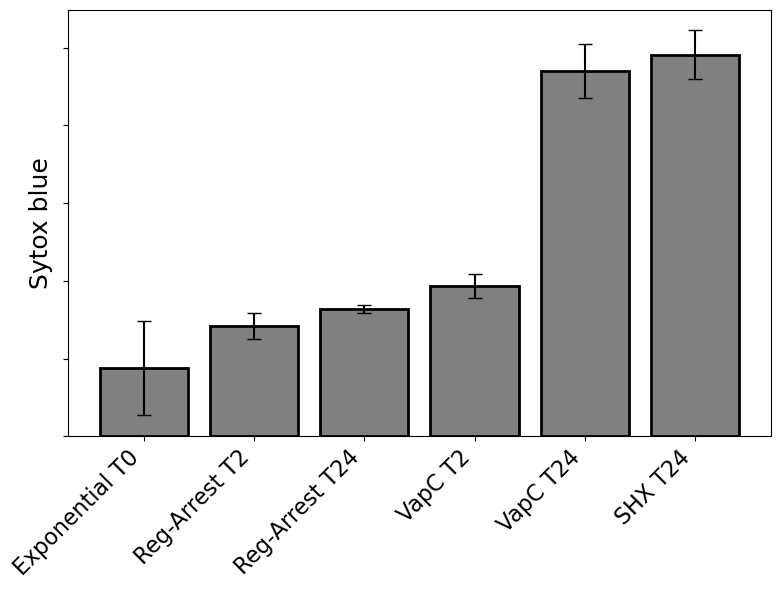

In [2]:
# figure s5:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.stats import t
f_size = 18
dir = r"G:\Other computers\My MacBook Air\Alon\PhD\correlations paper\new figures\supplementary figures\figure s5"
# Load data
df = pd.read_csv(os.path.join(dir, 'barplot_data_supp.csv'))
# plot bar plots from the data with error bars:
fig, ax = plt.subplots(figsize=(8, 6))
# plot the data
x = np.arange(len(df.index))
ax.bar(x, df['mean'], yerr=df['error'], capsize=5, color='grey', edgecolor='black', linewidth=2)
# set labels
labels = df.index
ax.set_xticks(x)
ax.set_xticklabels(df['Unnamed: 0'], fontsize=f_size-2, rotation=45, ha='right')
ax.set_ylabel('Sytox blue', fontsize=f_size)
ax.set_yticklabels([])
plt.tight_layout()
# save as svg
plt.savefig(os.path.join(dir, 'barplot.svg'), format='svg')

plt.show

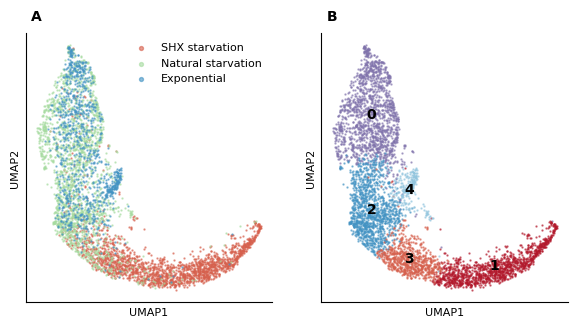

In [27]:
fig, ax = plt.subplots(1,2,figsize=(7,3.5))
fsize = 10
data = pd.read_csv(os.path.join(os.path.dirname(os.getcwd()), 'scanpy', 'umap_coordinates.csv'), index_col=0,
                   header=0)
# scatter plot
exp_data = data[data['batch'] == 'exp']

reg_data = data[np.logical_or(data['batch'] == 'reg1', data['batch'] == 'reg2')]
dis_data = data[np.logical_or(data['batch'] == 'dis1', data['batch'] == 'dis2')]
colors = ['#4393c3', '#a6dba0', '#d6604d']
ax[0].scatter(dis_data.UMAP_1, dis_data.UMAP_2, color=colors[2], alpha=.6, s=.5, label='SHX starvation')
ax[0].scatter(reg_data.UMAP_1, reg_data.UMAP_2, color=colors[1], alpha=.6, s=.5, label='Natural starvation')
ax[0].scatter(exp_data.UMAP_1, exp_data.UMAP_2, color=colors[0], alpha=.6, s=.5, label='Exponential')
ax[0].legend(fontsize=fsize-2, loc='upper right', bbox_to_anchor=(1,1), markerscale=4, frameon=False)
# second subplot
colors = ['#8073ac', '#b2182b','#4393c3', '#d6604d', '#92c5de']
# color by cluster
for i in range(max(data['cluster']) + 1):
    ax[1].scatter(data[data['cluster'] == i].UMAP_1, data[data['cluster'] == i].UMAP_2, color=colors[i], alpha=.6, s=.5,
               label=f"Cluster {i + 1}")
    ax[1].text(data[data['cluster'] == i].UMAP_1.mean(), data[data['cluster'] == i].UMAP_2.mean(), str(i),
            fontsize=fsize, fontweight='bold', color='k', ha='center', va='center')

for a in ax:
    # remove spines
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.set_xticks([])
    a.set_yticks([])
    a.set_xlabel('UMAP1', fontsize=fsize-2)
    a.set_ylabel('UMAP2', fontsize=fsize-2)

ax[0].text(-4,4.2,'A', fontsize = fsize, fontweight='bold')
ax[1].text(-4,4.2,'B', fontsize = fsize, fontweight='bold')
plt.savefig(r'G:\Other computers\My MacBook Air\Alon\PhD\correlations paper\new figures\supplementary figures\figure s6.pdf', dpi=300)
plt.show()

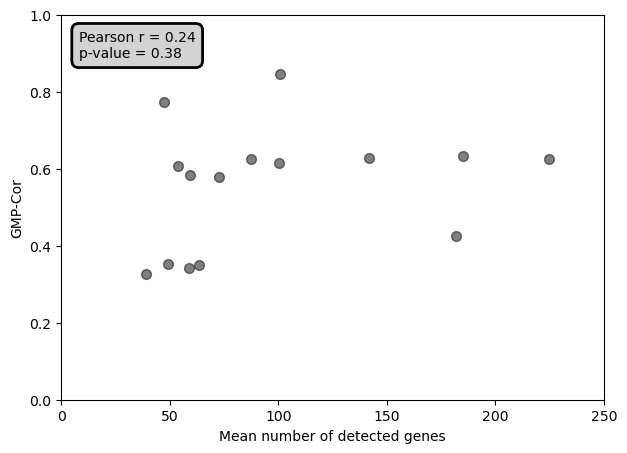

In [13]:
# GMP-Cor - gene detection correlation
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import numpy as np
import os
import pandas as pd

fontsize=10
blue='#3182bd'
red='#de2d26'
# load data
path = "G:\Other computers\My MacBook Air\Alon\PhD\correlations paper\summary of datasets\dataset_summary_no_plasmid_genes.csv"
df = pd.read_csv(path, header=0)

# Create scatter plot
fig, ax = plt.subplots(figsize=(7, 5))
# get pearson correlation
r, pval = pearsonr(df['mean_genes'], df['sigma fit'])

ax.scatter(df['mean_genes'], df['sigma fit'], s=50,c='k', alpha=0.5)
ax.set_xlabel('Mean number of detected genes', fontsize=fontsize)
ax.set_ylabel('GMP-Cor', fontsize=fontsize)
# set xtick size
ax.tick_params(axis='x', labelsize=fontsize)
# set ytick size
ax.tick_params(axis='y', labelsize=fontsize)
text = ax.text(
    8, 0.92,  # Position in axis coordinates (x=0.5, y=0.8)
    f"Pearson r = {r:.2}\np-value = {pval:.2}",  # Text content
    fontsize=fontsize,
    color='black',
    ha='left',  # Horizontal alignment
    va='center',  # Vertical alignment
    bbox=dict(
        boxstyle="round,pad=0.5",  # Rounded rectangle with padding
        edgecolor="black",  # Border color
        facecolor="lightgray",# Background color
        linewidth=2  # Border thickness
    )
)
ax.set_xlim([0, 250])
ax.set_ylim([0, 1])
# save the figure
output_dir = r'G:\Other computers\My MacBook Air\Alon\PhD\correlations paper\new figures\supplementary figures'
plt.savefig(os.path.join(output_dir, 'figure s7.pdf'), format='pdf')
plt.show()